In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/churn_clean.csv')

print(df.shape)
print(df['event'].value_counts())
print(f"Churn rate: {df['event'].mean()*100:.1f}%")

(7043, 26)
event
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 26.5%


C:\Users\jagra\AppData\Local\Temp\ipykernel_11944\2098021233.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x='Contract', y='churn_pct',
C:\Users\jagra\AppData\Local\Temp\ipykernel_11944\2098021233.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[2],


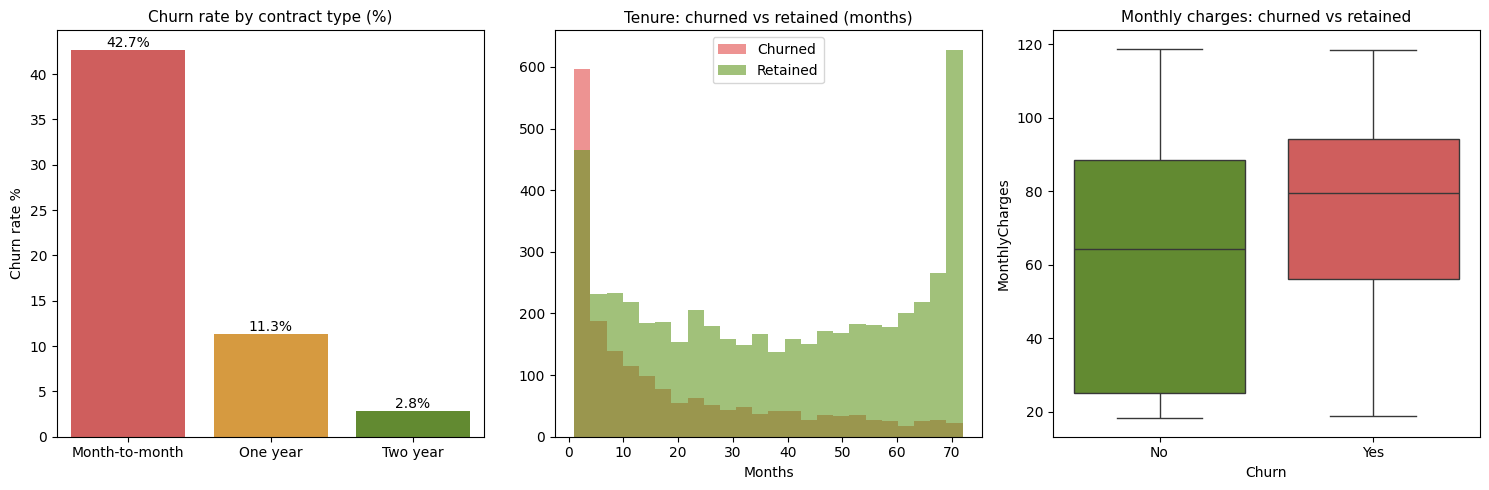

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1 — Churn rate by contract type
contract_churn = df.groupby('Contract')['event'].mean().reset_index()
contract_churn['churn_pct'] = (contract_churn['event'] * 100).round(1)

sns.barplot(data=contract_churn, x='Contract', y='churn_pct', 
            ax=axes[0], palette=['#E24B4A','#EF9F27','#639922'])
axes[0].set_title('Churn rate by contract type (%)', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Churn rate %')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom', fontsize=10)

# Chart 2 — Tenure distribution
churned = df[df['event']==1]['survival_time']
retained = df[df['event']==0]['survival_time']
axes[1].hist(churned, bins=24, alpha=0.6, label='Churned', color='#E24B4A')
axes[1].hist(retained, bins=24, alpha=0.6, label='Retained', color='#639922')
axes[1].set_title('Tenure: churned vs retained (months)', fontsize=11)
axes[1].set_xlabel('Months')
axes[1].set_ylabel('Number of customers')
axes[1].legend()

# Chart 3 — Monthly charges boxplot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[2],
            palette={'No':'#639922','Yes':'#E24B4A'})
axes[2].set_title('Monthly charges: churned vs retained', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/charts/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()